In [30]:
 # function for reading log.txt and calculating the average AUC and MCC etc
import numpy as np

def read_log_file(log_path):

    auc_list = []
    mcc_list = []
    prc_list = []

    with open(log_path, "r") as log_file:
        lines = log_file.readlines()

        for line in lines:
            # if line.startswith("Model:"):
            #     model_list.append(line.strip())

            if line.startswith("AUC:"):
                auc_value = float(line.split(":")[1].strip())
                auc_list.append(auc_value)

            elif line.startswith("MCC:"):
                mcc_value = float(line.split(":")[1].strip())
                mcc_list.append(mcc_value)
            
            elif line.startswith("AUPRC"):
                prc_value = float(line.split(":")[1].strip())
                prc_list.append(prc_value)    

    avg_auc = sum(auc_list) / len(auc_list) if auc_list else 0
    avg_mcc = sum(mcc_list) / len(mcc_list) if mcc_list else 0


    print(f"Average AUC: {avg_auc:.4f}")
    print(f"Average MCC: {avg_mcc:.4f}")
    
    print(f"\nStd dev AUC: {np.std(auc_list):.4f}")
    print(f"Std dev MCC: {np.std(mcc_list):.4f}")

    return 

read_log_file(r'M:\ML_scripts\MODEL DATA\RS_datasets\RS_100_models\run_2_models\log2.txt')

Average AUC: 0.6867
Average MCC: 0.1484

Std dev AUC: 0.0297
Std dev MCC: 0.0263


# load model files, make preds to get tpr/fpr and plot ROC curves

Avg AP: 0.1291, Std AP: 0.0216
0.04112398997414961


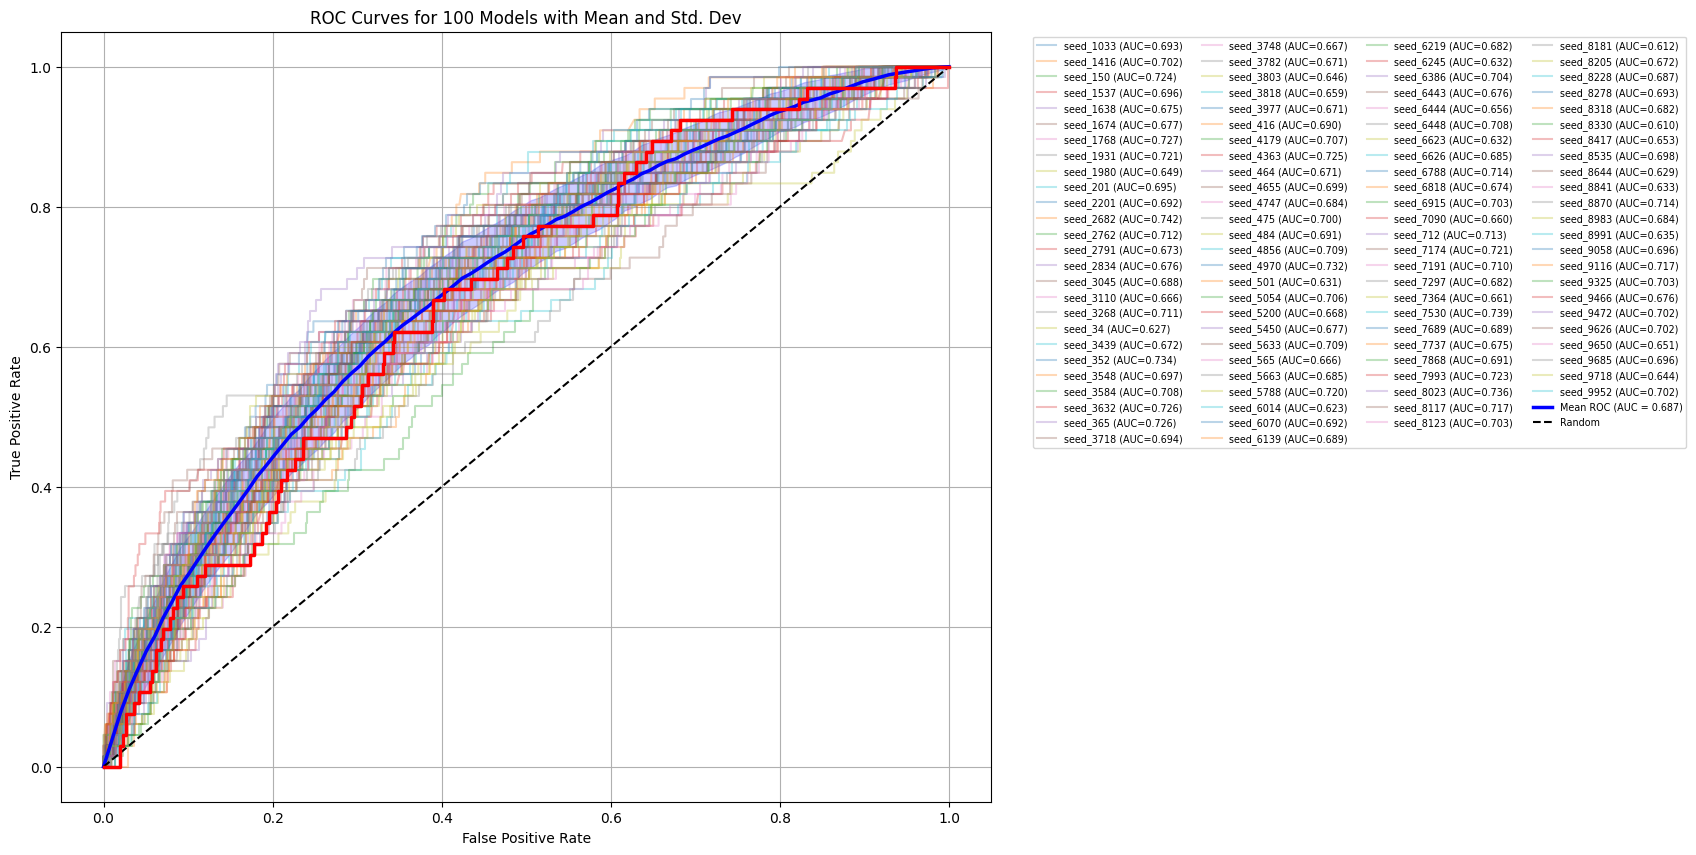

In [37]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn import *
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, average_precision_score
import numpy as np
from numpy import interp


def plot_roc(rs_sets_folder, models_folder):

    """
    Loads 100 models + test sets, plots individual ROC curves, a mean ROC, and a shaded std band.
    
    Parameters:
    - rs_sets_folder: folder with subfolders seed_*/test.csv
    - models_folder: folder with models named seed_<num>_model.pkl
    """

    plt.figure(figsize=(12, 10))
    mean_fpr = np.linspace(0, 1, 100)
    all_tprs = []
    ap_list = []
    processed = 0

    for seed_folder in sorted(os.listdir(rs_sets_folder)):
        full_seed_path = os.path.join(rs_sets_folder, seed_folder)

        if not os.path.isdir(full_seed_path) or not seed_folder.startswith("seed_"):
            continue

        seed = seed_folder.split("_")[1]
        model_filename = f"seed_{seed}_model.pkl"
        model_path = os.path.join(models_folder, model_filename)
        test_csv_path = os.path.join(full_seed_path, "test.csv")

        try:
            with open(model_path, "rb") as f:
                model = pickle.load(f)

            df = pd.read_csv(test_csv_path)
            smiles = df["Structure"]
            true = df["Class"]

            preds = model.predict_from_smiles(smiles)
            fpr, tpr, thresh = roc_curve(true, preds)
            roc_auc = np.trapz(tpr, fpr)

            # opt_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
            # opt_thresh = thresh[opt_idx]

            # pred_bin = [1 if value >= opt_thresh else 0 for value in preds]

            # PR curve mean

            # precision, recall, _ = precision_recall_curve(true, preds)
            # ap = PrecisionRecallDisplay.from_predictions(true, preds)
            
            ap = average_precision_score(true, preds)
            ap_list.append(ap)

            # ROC curve interpolation

            interp_tpr = interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            all_tprs.append(interp_tpr)

            if processed < 100:
                plt.plot(fpr, tpr, alpha=0.3, label=f'seed_{seed} (AUC={roc_auc:.3f})')
            else:
                plt.plot(fpr, tpr, alpha=0.3)

            processed += 1

        except Exception as e:
            print(f"[Warning] Skipping seed_{seed}: {e}")

    if all_tprs:
        all_tprs = np.array(all_tprs)
        mean_tpr = np.mean(all_tprs, axis=0)
        std_tpr = np.std(all_tprs, axis=0)
        mean_tpr[-1] = 1.0

        mean_auc = np.trapz(mean_tpr, mean_fpr)
        plt.plot(mean_fpr, mean_tpr, color='blue', lw=2.5, label=f'Mean ROC (AUC = {mean_auc:.3f})')

        # Plot shaded standard deviation
        tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
        tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
        plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color='blue', alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for 100 Models with Mean and Std. Dev')
    plt.grid(True)
    plt.legend(fontsize='x-small', loc='upper left', ncol=4, bbox_to_anchor=(1.04, 1))

    # current TM1 model ROC curve

    with open("M:/ML_scripts/MODEL DATA/models/composite models/main_NM_model.pkl", "rb") as f:
        tm1 = pickle.load(f)

    tm1_test = pd.read_csv(r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_test_NM-RS42.csv')
    tm1_smiles = tm1_test["Structure"]
    tm1_true = tm1_test["Class"]

    tm1_preds = tm1.predict_from_smiles(tm1_smiles)
    tm1_fpr, tm1_tpr, tm1_thresh = roc_curve(tm1_true, tm1_preds)
    tm1_roc_auc = np.trapz(tm1_tpr, tm1_fpr)

    plt.plot(tm1_fpr, tm1_tpr, color='red', lw=2.5, label=f'Tobramycin Model (AUC = {tm1_roc_auc:.3f})')

    print(f"Avg AP: {np.mean(ap_list):.4f}, Std AP: {np.std(ap_list):.4f}")
    # print(tpr_upper)
    # print(tpr_lower)
    print(np.mean(std_tpr))

plot_roc(r'M:\ML_scripts\MODEL DATA\RS_datasets\RS_100_sets', r'M:\ML_scripts\MODEL DATA\RS_datasets\RS_100_models\run_2_models')